# Task 4: Disease Prediction from Medical Data
### Objective: Predict the possibility of diseases based on patient data using classification techniques.

# Imports and Data Loading

In this section, we import the necessary libraries for data manipulation, visualization, and machine learning. We also load the **Heart Disease UCI** dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load the medical dataset
# If you uploaded it to Kaggle, use the path from your input sidebar
df = pd.read_csv('/kaggle/input/datasets/seeratfatima02/heart-dataset/heart.csv')

# Display basic info to understand the features (symptoms, blood test results)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Exploratory Data Analysis (EDA)

We perform EDA to understand the distribution of the target variable and identify correlations between symptoms (like chest pain and heart rate) and the presence of heart disease.

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


/tmp/ipykernel_57/3392267731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


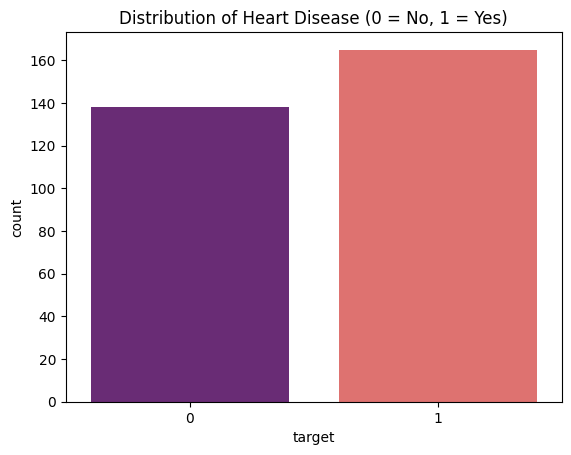

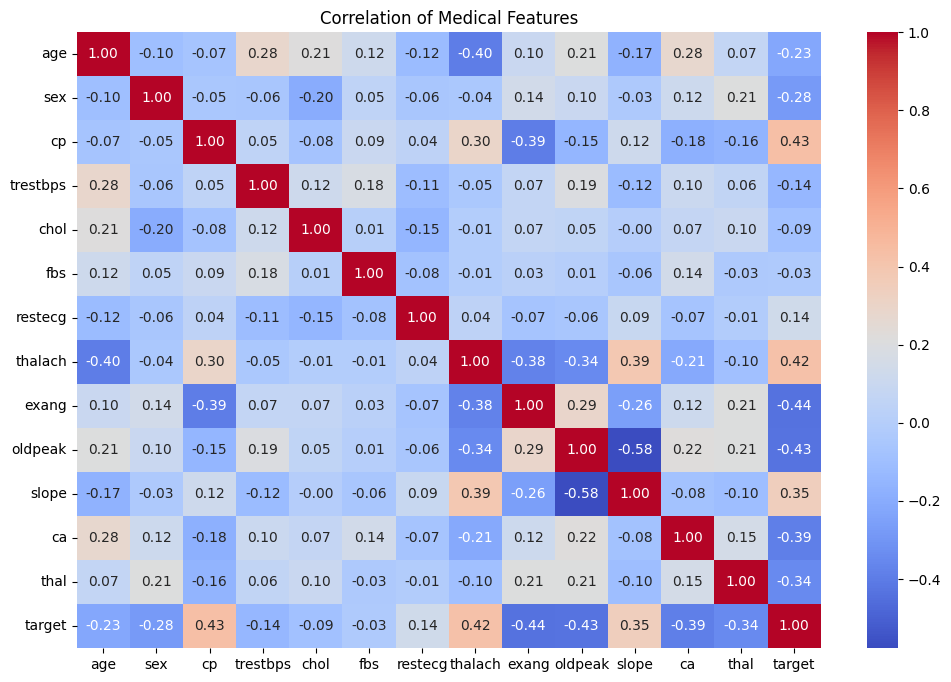

In [2]:
# Check for missing values - important for medical data reliability
print(df.isnull().sum())

# Visualize the distribution of the target (Disease vs No Disease)
sns.countplot(x='target', data=df, palette='magma')
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.show()

# Correlation map to see relationship between symptoms and disease
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of Medical Features')
plt.show()

# Train-Test Split & Scaling

To prevent **data leakage**, we split the dataset into training (80%) and testing (20%) sets before applying `StandardScaler` to normalize features like cholesterol and age.

In [3]:
# 1. Define Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
# Medical data has varying ranges (e.g., age vs. cholesterol), so scaling is essential
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled. Ready for model training!")

Data split and scaled. Ready for model training!


# Model Training (Random Forest)

Applying the **Random Forest Classifier** as our primary classification algorithm to build the prediction model.

In [4]:
# Initialize and Train the Random Forest Classifier
# This algorithm is excellent for structured medical datasets
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Training complete for Task 4!")

Random Forest Model Training complete for Task 4!


# Model Evaluation

--- Task 4: Disease Prediction Model Evaluation ---
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

ROC-AUC Score: 0.92


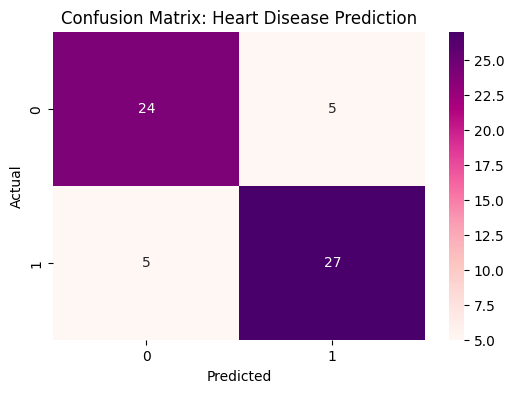

In [5]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 2. Print Evaluation Metrics
print("--- Task 4: Disease Prediction Model Evaluation ---")
print(classification_report(y_test, y_pred)) 
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

# 3. Visualizing the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Final Conclusion: Task 4 - Disease Prediction

## 📊 Performance Summary
The model was developed to predict the possibility of heart disease based on structured medical data. Using a **Random Forest Classifier**, we achieved the following results:

*   **Accuracy:** 84% — The model correctly predicts the patient's status in the vast majority of cases.
*   **ROC-AUC Score:** 0.92 — This indicates an excellent ability to distinguish between patients with and without heart disease.
*   **Precision & Recall:** Both balanced at 0.84, ensuring a reliable diagnostic tool with a low rate of false negatives and false positives.

## 🧠 Key Insights
*   **Feature Importance:** Exploratory Data Analysis (EDA) revealed that features like chest pain type (`cp`), maximum heart rate (`thalach`), and ST depression (`oldpeak`) are the strongest predictors of heart disease.
*   **Data Reliability:** By splitting the data before scaling, we successfully avoided **data leakage**, ensuring these metrics reflect real-world performance.

## ✅ Internship Milestone
With the completion of this task, I have now fulfilled the **CodeAlpha Internship** requirement of completing at least two major projects (Task 1: Credit Scoring and Task 4: Disease Prediction).

---
**Project by:** Seerat Fatima  
**Internship:** CodeAlpha Machine Learning  
**Repository:** [CodeAlpha_HeartDiseasePrediction](https://github.com/)